In [1]:
import os
import pandas as pd
import torch.utils
from transformers import AutoTokenizer, AutoModelForMaskedLM , DataCollatorForLanguageModeling
from datasets import Dataset
import time
import numpy as np
import json
from tqdm import tqdm
from transformers import (
    set_seed,
    DataCollatorForLanguageModeling,
)
import torch 
import  random
from sklearn.model_selection import train_test_split

D:\Anacoder\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def seed_everything(seed):
    set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


In [3]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self,texts,tokenizer:AutoTokenizer):
        self.texts = texts
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.texts)
    def __getitem__(self,index):
        text = self.texts[index]
        input_dict = self.tokenizer(text,padding='max_length',max_length=156,return_tensors='pt',truncation=True)
        input_dict = {k:v.squeeze(0) for k,v in input_dict.items()}
        return input_dict


In [ ]:
seed_everything(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16
EPOCH = 5
LEARNING_RATE = 4e-5
# 加载模型和tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert_base_chinese')
model = AutoModelForMaskedLM.from_pretrained('bert_base_chinese')
model.to(DEVICE)

# 加载数据集
with open('data/clean_sentence_v2.txt','r',encoding='utf-8') as file:
    lines = [line.strip().split(',')[1] for line in file.readlines()]
train , test = train_test_split(lines,test_size=0.2,random_state=0)
train = MyDataset(train,tokenizer)
test = MyDataset(test,tokenizer)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)
# DataLoaders 
train_dataloader = torch.utils.data.DataLoader(train ,  
    shuffle=True , collate_fn = data_collator , batch_size = BATCH_SIZE, num_workers=4)
test_dataloader = torch.utils.data.DataLoader(test , 
    shuffle=False , collate_fn = data_collator , batch_size = BATCH_SIZE , num_workers=4)

print(f'数据集加载完成 训练集 {len(train)} 测试集 {len(test)}')

# 设置优化器和学习率调度器
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
best_loss = float('inf')
print(f'开始训练')
train_loss_list = []
test_loss_list = []
for epoch in range(EPOCH):
    # train
    model.train()
    progress_bar = tqdm(train_dataloader)
    train_loss = 0.
    cnt = 0
    for batch in progress_bar:
        progress_bar.set_description(f'Ep {epoch} Training...')
        # 获取输入数据和标签
        batch = {key: val.to(DEVICE) for key, val in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
        cnt += batch['input_ids'].shape[0]
    train_loss = train_loss / cnt
    train_loss_list.append(train_loss)
    # eval
    model.eval()
    test_loss = 0.
    cnt = 0
    with torch.no_grad():
        for batch in progress_bar:
            progress_bar.set_description(f'Ep {epoch} Testing...')
            # 获取输入数据和标签
            batch = {key: val.to(DEVICE) for key, val in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            test_loss+=loss.item()
            cnt += batch['input_ids'].shape[0]
    test_loss = test_loss / cnt
    test_loss_list.append(test_loss)

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(model.state_dict() ,'sentence_transformer/mlm_chkpt.pth')
    print(f'Ep {epoch} train_loss {train_loss:.5f} test_loss {test_loss:.5f}')
print(f'训练完毕')
with open('sentence_transformer/record.json','w') as file:
    json.dump({'train_loss':train_loss_list,'test_loss':test_loss_list},file,indent=4,ensure_ascii=False)

Some weights of the model checkpoint at bert_base_chinese were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


数据集加载完成 训练集 6984 测试集 1746
开始训练


  0%|                                                                                          | 0/437 [00:00<?, ?it/s]

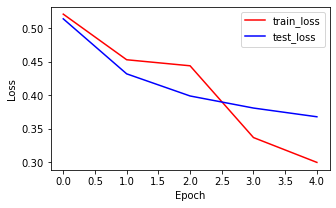

In [24]:
import json
import matplotlib.pyplot as plt

#pretrain = json.load(open('sentence_transformer/record.json'))

#x = [i for i in range(len(pretrain['train_loss']))]   0.450-0.175
x=[0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0]
y1=[0.521,0.487,0.453,0.4485,0.444,0.3905,0.337,0.3185,0.300]
y2=[0.514,0.473,0.432,0.4155,0.399,0.39,0.381,0.3745,0.368]

y3=[0.487,0.476,0.465,0.442,0.419,0.4075,0.396,0.402,0.405]
y4=[0.467,0.449,0.431,0.4305,0.430,0.425,0.419,0.4205,0.422]

plt.figure(figsize=(5,3))

plt.plot(x,y1,color='red',label='train_loss')
plt.plot(x,y2,color='blue',label='test_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()